In [14]:
from pathlib import Path
import sys

project_root = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "src" / "target.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find src/target.py in the current directory or its parents")

sys.path.insert(0, str(project_root))

from src.target import build_target

In [15]:
import pandas as pd
from src.target import build_target
import numpy as np

apps = pd.read_csv(r"C:\Coding Folders\hilbit_ai_assignment\data\loan_applications.csv")
repayments = pd.read_csv(r"C:\Coding Folders\hilbit_ai_assignment\data\repayment_history.csv")

# Build target
target_df = build_target(repayments, as_of="2026-08-31")

# Merge
df = apps.merge(target_df, on="application_id", how="inner")

# Keep only fully observed loans for training
df_train = df[df["is_fully_observed"] == True].copy()

print(df_train["default_90dpd_12m"].value_counts(normalize=True))
print(df_train.shape)

default_90dpd_12m
0    0.897262
1    0.102738
Name: proportion, dtype: float64
(14863, 34)


In [16]:
df_train["application_date"] = pd.to_datetime(df_train["application_date"], format="%d-%m-%Y")

# Then the split
train = df_train[df_train["application_date"] < "2025-04-01"]
val   = df_train[df_train["application_date"] >= "2025-04-01"]

print("Train size:", train.shape[0], "| Bad rate:", train["default_90dpd_12m"].mean().round(3))
print("Val size:  ", val.shape[0],   "| Bad rate:", val["default_90dpd_12m"].mean().round(3))

Train size: 13875 | Bad rate: 0.106
Val size:   988 | Bad rate: 0.06


In [17]:
def engineer_features(df):
    df = df.copy()
    
    # Fix 1: bureau_score — separate the -1 sentinel from real scores
    df["is_new_to_credit"] = (df["bureau_score"] == -1).astype(int)
    df["bureau_score_clean"] = df["bureau_score"].replace(-1, np.nan)
    df = df.drop(columns=["bureau_score"])
    
    # Fix 2: FOIR — flag then cap
    df["foir_above_100"] = (df["foir_pct"] > 100).astype(int)
    df["foir_pct"] = df["foir_pct"].clip(upper=100)
    
    # Fix 3: application_date already parsed — extract month for seasonality
    df["application_month"] = df["application_date"].dt.month
    
    return df

# Apply to both
train_fe = engineer_features(train)
val_fe   = engineer_features(val)

# Update column lists
NUM_COLS_FE = [
    "age", "monthly_income", "years_at_residence",
    "bureau_score_clean",           # ← clean version
    "is_new_to_credit",             # ← new flag
    "bureau_vintage_months", "enquiries_last_6m",
    "existing_emi", "on_road_price", "down_payment",
    "loan_amount", "ltv_pct", "tenure_months",
    "interest_rate_pct", "emi", "foir_pct",
    "foir_above_100",               # ← new flag
    "has_coapplicant", "application_month"
]

CAT_COLS_FE = [
    "city_tier", "state", "occupation_type", "income_proof_type",
    "residence_type", "vehicle_segment", "sourcing_channel", "dealer_id"
    # removed city and pincode — too high cardinality, use state/city_tier instead
]

X_train_fe = train_fe[NUM_COLS_FE + CAT_COLS_FE]
y_train_fe = train_fe["default_90dpd_12m"]
X_val_fe   = val_fe[NUM_COLS_FE + CAT_COLS_FE]
y_val_fe   = val_fe["default_90dpd_12m"]

print("Nulls in X_train after engineering:", X_train_fe.isnull().sum().sum())
print("Shape:", X_train_fe.shape)

Nulls in X_train after engineering: 3233
Shape: (13875, 27)


In [18]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
import shap

os.makedirs("models", exist_ok=True)
RANDOM_SEED = 42

# ── Load data ────────────────────────────────────────────────
apps       = pd.read_csv(r"C:\Coding Folders\hilbit_ai_assignment\data\loan_applications.csv")
repayments = pd.read_csv(r"C:\Coding Folders\hilbit_ai_assignment\data\repayment_history.csv")

from src.target import build_target
target_df = build_target(repayments, as_of="2026-08-31")

df = apps.merge(target_df, on="application_id", how="inner")
df = df[df["is_fully_observed"] == True].copy()
df["application_date"] = pd.to_datetime(df["application_date"], format="%d-%m-%Y")

# ── Feature engineering ──────────────────────────────────────
def engineer_features(df):
    df = df.copy()
    df["is_new_to_credit"]   = (df["bureau_score"] == -1).astype(int)
    df["bureau_score_clean"] = df["bureau_score"].replace(-1, np.nan)
    df = df.drop(columns=["bureau_score"])
    df["foir_above_100"] = (df["foir_pct"] > 100).astype(int)
    df["foir_pct"]       = df["foir_pct"].clip(upper=100)
    df["application_month"] = df["application_date"].dt.month
    return df

df = engineer_features(df)

# ── Time-based split ─────────────────────────────────────────
train = df[df["application_date"] < "2025-04-01"].copy()
val   = df[df["application_date"] >= "2025-04-01"].copy()

print(f"Train: {train.shape[0]} rows | Bad rate: {train['default_90dpd_12m'].mean():.3f}")
print(f"Val:   {val.shape[0]} rows   | Bad rate: {val['default_90dpd_12m'].mean():.3f}")

# ── Explicit feature lists (no auto-detection) ───────────────
NUM_COLS = [
    "age", "monthly_income", "years_at_residence",
    "bureau_score_clean", "is_new_to_credit",
    "bureau_vintage_months", "enquiries_last_6m",
    "existing_emi", "on_road_price", "down_payment",
    "loan_amount", "ltv_pct", "tenure_months",
    "interest_rate_pct", "emi", "foir_pct",
    "foir_above_100", "has_coapplicant", "application_month"
]

CAT_COLS = [
    "city_tier", "state", "occupation_type", "income_proof_type",
    "residence_type", "vehicle_segment", "sourcing_channel", "dealer_id"
]

X_train = train[NUM_COLS + CAT_COLS]
y_train = train["default_90dpd_12m"]
X_val   = val[NUM_COLS + CAT_COLS]
y_val   = val["default_90dpd_12m"]

print(f"\nFeatures: {len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical")
print(f"Nulls in X_train: {X_train.isnull().sum().sum()}")

# ── Preprocessor ─────────────────────────────────────────────
def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
        ]), NUM_COLS),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), CAT_COLS),
    ])

# ── Logistic Regression ──────────────────────────────────────
lr_pipe = Pipeline([
    ("prep",  make_preprocessor()),
    ("model", LogisticRegression(max_iter=3000, solver="saga", random_state=RANDOM_SEED))
])
lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict_proba(X_val)[:, 1]
lr_auc   = roc_auc_score(y_val, lr_preds)
lr_gini  = 2 * lr_auc - 1
lr_ks    = ks_2samp(lr_preds[y_val == 1], lr_preds[y_val == 0]).statistic
print(f"\nLogistic Regression:")
print(f"  AUC:  {lr_auc:.4f}")
print(f"  Gini: {lr_gini:.4f}")
print(f"  KS:   {lr_ks:.4f}")

# ── XGBoost ──────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ("prep",  make_preprocessor()),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_SEED,
        eval_metric="auc",
    ))
])
xgb_pipe.fit(X_train, y_train)
xgb_preds = xgb_pipe.predict_proba(X_val)[:, 1]
xgb_auc   = roc_auc_score(y_val, xgb_preds)
xgb_gini  = 2 * xgb_auc - 1
xgb_ks    = ks_2samp(xgb_preds[y_val == 1], xgb_preds[y_val == 0]).statistic
print(f"\nXGBoost:")
print(f"  AUC:  {xgb_auc:.4f}")
print(f"  Gini: {xgb_gini:.4f}")
print(f"  KS:   {xgb_ks:.4f}")

# ── Calibration check ────────────────────────────────────────
print("\n── Calibration (XGBoost) ──")
cal_df = pd.DataFrame({"pred": xgb_preds, "actual": y_val.values})
cal_df["decile"] = pd.qcut(cal_df["pred"], q=10, labels=False, duplicates="drop")
cal_table = cal_df.groupby("decile").agg(
    mean_pred=("pred", "mean"),
    actual_bad_rate=("actual", "mean"),
    count=("actual", "count")
).reset_index()
print(cal_table.to_string(index=False))

# ── Feature importance ───────────────────────────────────────
print("\n── Feature Importance (XGBoost) ──")
feature_names = NUM_COLS + CAT_COLS
importances   = xgb_pipe.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({
    "feature":    feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
print(feat_imp.head(10).to_string(index=False))

# ── SHAP for 5 rejected applicants ──────────────────────────
print("\n── SHAP: Top 3 rejection reasons ──")
X_val_transformed = xgb_pipe.named_steps["prep"].transform(X_val)
explainer = shap.TreeExplainer(xgb_pipe.named_steps["model"])
shap_vals = explainer.shap_values(X_val_transformed)

top5_idx = np.argsort(xgb_preds)[-5:][::-1]
for i, idx in enumerate(top5_idx):
    shap_row  = shap_vals[idx]
    top3_feat = np.argsort(np.abs(shap_row))[-3:][::-1]
    print(f"\nApplicant {i+1} | PD score: {xgb_preds[idx]:.3f}")
    for rank, feat_idx in enumerate(top3_feat):
        fname = feature_names[feat_idx]
        fval  = X_val.iloc[idx][fname]
        direction = "increases" if shap_row[feat_idx] > 0 else "decreases"
        print(f"  Reason {rank+1}: {fname} = {fval} → {direction} default risk")

# ── Save ─────────────────────────────────────────────────────
joblib.dump(lr_pipe,      "models/lr_model.pkl")
joblib.dump(xgb_pipe,     "models/xgb_model.pkl")
joblib.dump(NUM_COLS,     "models/num_cols.pkl")
joblib.dump(CAT_COLS,     "models/cat_cols.pkl")
print("\nModels saved.")

Train: 13875 rows | Bad rate: 0.106
Val:   988 rows   | Bad rate: 0.060

Features: 19 numeric, 8 categorical
Nulls in X_train: 3233

Logistic Regression:
  AUC:  0.6403
  Gini: 0.2806
  KS:   0.2770

XGBoost:
  AUC:  0.6833
  Gini: 0.3666
  KS:   0.3383

── Calibration (XGBoost) ──
 decile  mean_pred  actual_bad_rate  count
      0   0.019439         0.020202     99
      1   0.033310         0.030303     99
      2   0.045391         0.030303     99
      3   0.058382         0.020408     98
      4   0.070889         0.040404     99
      5   0.086951         0.030303     99
      6   0.106456         0.102041     98
      7   0.134780         0.070707     99
      8   0.171248         0.101010     99
      9   0.312722         0.151515     99

── Feature Importance (XGBoost) ──
           feature  importance
          foir_pct    0.093351
bureau_score_clean    0.088678
         dealer_id    0.057134
   occupation_type    0.055606
 income_proof_type    0.047093
           ltv_pct    

In [19]:
print("NUM_COLS:", NUM_COLS)
print("CAT_COLS:", CAT_COLS)
print("Any nulls in X_train?", X_train.isnull().sum().sum())

NUM_COLS: ['age', 'monthly_income', 'years_at_residence', 'bureau_score_clean', 'is_new_to_credit', 'bureau_vintage_months', 'enquiries_last_6m', 'existing_emi', 'on_road_price', 'down_payment', 'loan_amount', 'ltv_pct', 'tenure_months', 'interest_rate_pct', 'emi', 'foir_pct', 'foir_above_100', 'has_coapplicant', 'application_month']
CAT_COLS: ['city_tier', 'state', 'occupation_type', 'income_proof_type', 'residence_type', 'vehicle_segment', 'sourcing_channel', 'dealer_id']
Any nulls in X_train? 3233


In [20]:
# Quick single-feature AUC check
from sklearn.metrics import roc_auc_score

# The feature engineering step replaces the -1 sentinel with NaN and drops bureau_score.
bureau = X_train["bureau_score_clean"].fillna(X_train["bureau_score_clean"].median())
bureau_val = X_val["bureau_score_clean"].fillna(X_train["bureau_score_clean"].median())
print("Bureau score alone AUC:", roc_auc_score(y_val, -bureau_val))

Bureau score alone AUC: 0.6208425316086188


In [21]:
###TESTING!!!!
# ── Generate test predictions ────────────────────────────────
test = pd.read_csv(r"C:\Coding Folders\hilbit_ai_assignment\data\loan_applications_test.csv")
test["application_date"] = pd.to_datetime(test["application_date"], format="%Y-%m-%d")
test = engineer_features(test)

X_test = test[NUM_COLS + CAT_COLS]
test_preds = xgb_pipe.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "application_id": test["application_id"],
    "pd_score": test_preds
})
submission.to_csv("predictions_test.csv", index=False)
print("Saved predictions_test.csv")
print(submission["pd_score"].describe().round(3))
print(f"Average predicted PD: {test_preds.mean():.3f}")
print(f"Actual train bad rate: {y_train.mean():.3f}")
print(f"Calibration gap: {abs(test_preds.mean() - y_train.mean()):.3f}")

Saved predictions_test.csv
count    4450.000
mean        0.097
std         0.084
min         0.005
25%         0.043
50%         0.075
75%         0.121
max         0.749
Name: pd_score, dtype: float64
Average predicted PD: 0.097
Actual train bad rate: 0.106
Calibration gap: 0.009


Optimal PD cut-off:  0.327
Max expected profit: ₹4,250,857
Approval rate:       96.9%
Expected bad rate:   5.5%


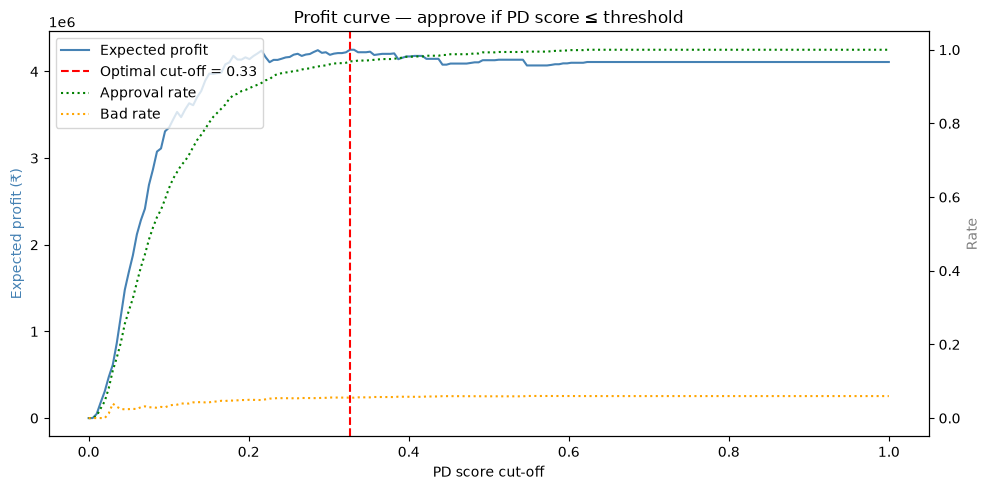

Saved profit_curve.png

New-to-credit bad rate: 0.068 | n=162
Bureau-filed bad rate:  0.058 | n=826

── Portfolio Insights ──

1. Bad rate by sourcing channel:
                   mean  count
sourcing_channel              
DSA               0.085    188
Dealer walk-in    0.059    564
Digital partner   0.051    157
Branch            0.025     79

2. Bad rate by occupation type:
                               mean  count
occupation_type                           
Student                       0.100     20
Gig / Delivery                0.093    162
Farmer                        0.060    116
Salaried - Private            0.057    350
Self-employed - Professional  0.052     58
Self-employed - Shop          0.045    223
Salaried - Govt               0.034     59

3. Bad rate by vehicle segment:
                     mean  count
vehicle_segment                 
Scooter 110cc       0.078    322
Premium 150cc+      0.069    175
Commuter 100-125cc  0.046    392
Electric scooter    0.040     99

Op

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ── Economics ────────────────────────────────────────────────
GOOD_RETURN  = 0.09   # 9% of loan amount earned on good loan
BAD_LOSS     = 0.55   # 55% of loan amount lost on bad loan

# Use validation set with actual loan amounts
val_with_loans = val.copy()
val_with_loans["pd_score"] = xgb_preds
val_with_loans = val_with_loans.sort_values("pd_score").reset_index(drop=True)

# ── Profit curve across all thresholds ──────────────────────
thresholds    = np.linspace(0, 1, 200)
profits       = []
approval_rates = []
expected_bad_rates = []

total_loans = len(val_with_loans)

for t in thresholds:
    approved = val_with_loans[val_with_loans["pd_score"] <= t]
    if len(approved) == 0:
        profits.append(0)
        approval_rates.append(0)
        expected_bad_rates.append(0)
        continue

    good = approved[approved["default_90dpd_12m"] == 0]
    bad  = approved[approved["default_90dpd_12m"] == 1]

    profit = (
        good["loan_amount"].sum() * GOOD_RETURN -
        bad["loan_amount"].sum()  * BAD_LOSS
    )
    profits.append(profit)
    approval_rates.append(len(approved) / total_loans)
    expected_bad_rates.append(bad.shape[0] / len(approved))

# ── Find optimal cut-off ─────────────────────────────────────
best_idx       = np.argmax(profits)
best_threshold = thresholds[best_idx]
best_profit    = profits[best_idx]
best_approval  = approval_rates[best_idx]
best_bad_rate  = expected_bad_rates[best_idx]

print(f"Optimal PD cut-off:  {best_threshold:.3f}")
print(f"Max expected profit: ₹{best_profit:,.0f}")
print(f"Approval rate:       {best_approval:.1%}")
print(f"Expected bad rate:   {best_bad_rate:.1%}")

# ── Plot ─────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresholds, profits, color="steelblue", label="Expected profit")
ax1.axvline(best_threshold, color="red", linestyle="--", label=f"Optimal cut-off = {best_threshold:.2f}")
ax1.set_xlabel("PD score cut-off")
ax1.set_ylabel("Expected profit (₹)", color="steelblue")
ax1.set_title("Profit curve — approve if PD score ≤ threshold")

ax2 = ax1.twinx()
ax2.plot(thresholds, approval_rates, color="green",  linestyle=":", label="Approval rate")
ax2.plot(thresholds, expected_bad_rates, color="orange", linestyle=":", label="Bad rate")
ax2.set_ylabel("Rate", color="gray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")


plt.tight_layout()
plot_path = project_root / "notebooks" / "profit_curve.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved profit_curve.png")

# ── NTC vs regular cut-off question ─────────────────────────
ntc  = val_with_loans[val_with_loans["is_new_to_credit"] == 1]
reg  = val_with_loans[val_with_loans["is_new_to_credit"] == 0]

print(f"\nNew-to-credit bad rate: {ntc['default_90dpd_12m'].mean():.3f} | n={len(ntc)}")
print(f"Bureau-filed bad rate:  {reg['default_90dpd_12m'].mean():.3f} | n={len(reg)}")

# ── 3 CRO portfolio insights ─────────────────────────────────
print("\n── Portfolio Insights ──")

# Insight 1: sourcing channel bad rates
print("\n1. Bad rate by sourcing channel:")
print(val_with_loans.groupby("sourcing_channel")["default_90dpd_12m"]
      .agg(["mean", "count"]).round(3).sort_values("mean", ascending=False))

# Insight 2: occupation type bad rates  
# Fix occupation type print
print("\n2. Bad rate by occupation type:")
print(val_with_loans.groupby("occupation_type")["default_90dpd_12m"]
      .agg(["mean", "count"]).round(3).sort_values("mean", ascending=False).to_string())

print("\n3. Bad rate by vehicle segment:")
print(val_with_loans.groupby("vehicle_segment")["default_90dpd_12m"]
      .agg(["mean", "count"]).round(3).sort_values("mean", ascending=False).to_string())

# Also print the cut-off numbers
print(f"\nOptimal PD cut-off:  {best_threshold:.3f}")
print(f"Approval rate at cut-off: {best_approval:.1%}")
print(f"Expected bad rate at cut-off: {best_bad_rate:.1%}")